# Phase 1 — Feature / label EDA
Distributions overall and per damage stage, per-specimen feature-vs-deflection panels, and the feature correlation matrix. Source table: `data/processed/features.parquet`.

In [1]:
import sys; sys.path.insert(0, '..')
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.features.engineering import FEATURE_COLUMNS
from src.features.labels import STAGE_NAMES
plt.rcParams.update({'font.family': 'serif', 'figure.dpi': 130})
FIG = Path('../reports/figures/phase1'); FIG.mkdir(parents=True, exist_ok=True)
df = pd.read_parquet('../data/processed/features.parquet')
df.describe().T

,count,mean,std,min,25%,50%,75%,max
t,23555.0,266.701357,178.639525,0.083279,122.749946,245.416612,370.791612,731.083279
fcr,23555.0,9.068292,2.858479,-6.076060,6.732578,10.175717,11.167582,17.839533
dfcr_dD,23555.0,1.483417,10.117238,-49.637632,-0.225150,0.258460,1.026538,149.116019
d2fcr_dD2,23555.0,0.490720,208.196517,-2877.429063,-8.444941,-0.420358,8.619821,1812.616565
roll_mean_1mm,23555.0,8.722728,2.902113,-6.076060,5.742308,9.713036,10.918329,13.861087
roll_std_1mm,23555.0,0.343450,0.525790,0.000000,0.062805,0.127195,0.351076,2.660561
roll_mean_3mm,23555.0,8.418358,2.857024,-6.076060,5.597944,9.253055,10.671104,11.953288
roll_std_3mm,23555.0,0.745487,0.701473,0.000000,0.179512,0.394150,1.223153,2.660561
roll_mean_5mm,23555.0,8.248131,2.809496,-6.076060,5.495597,9.037840,10.566905,11.783101
roll_std_5mm,23555.0,1.029838,0.710055,0.000000,0.311105,0.902258,1.779091,2.660561


## Feature distributions (overall)

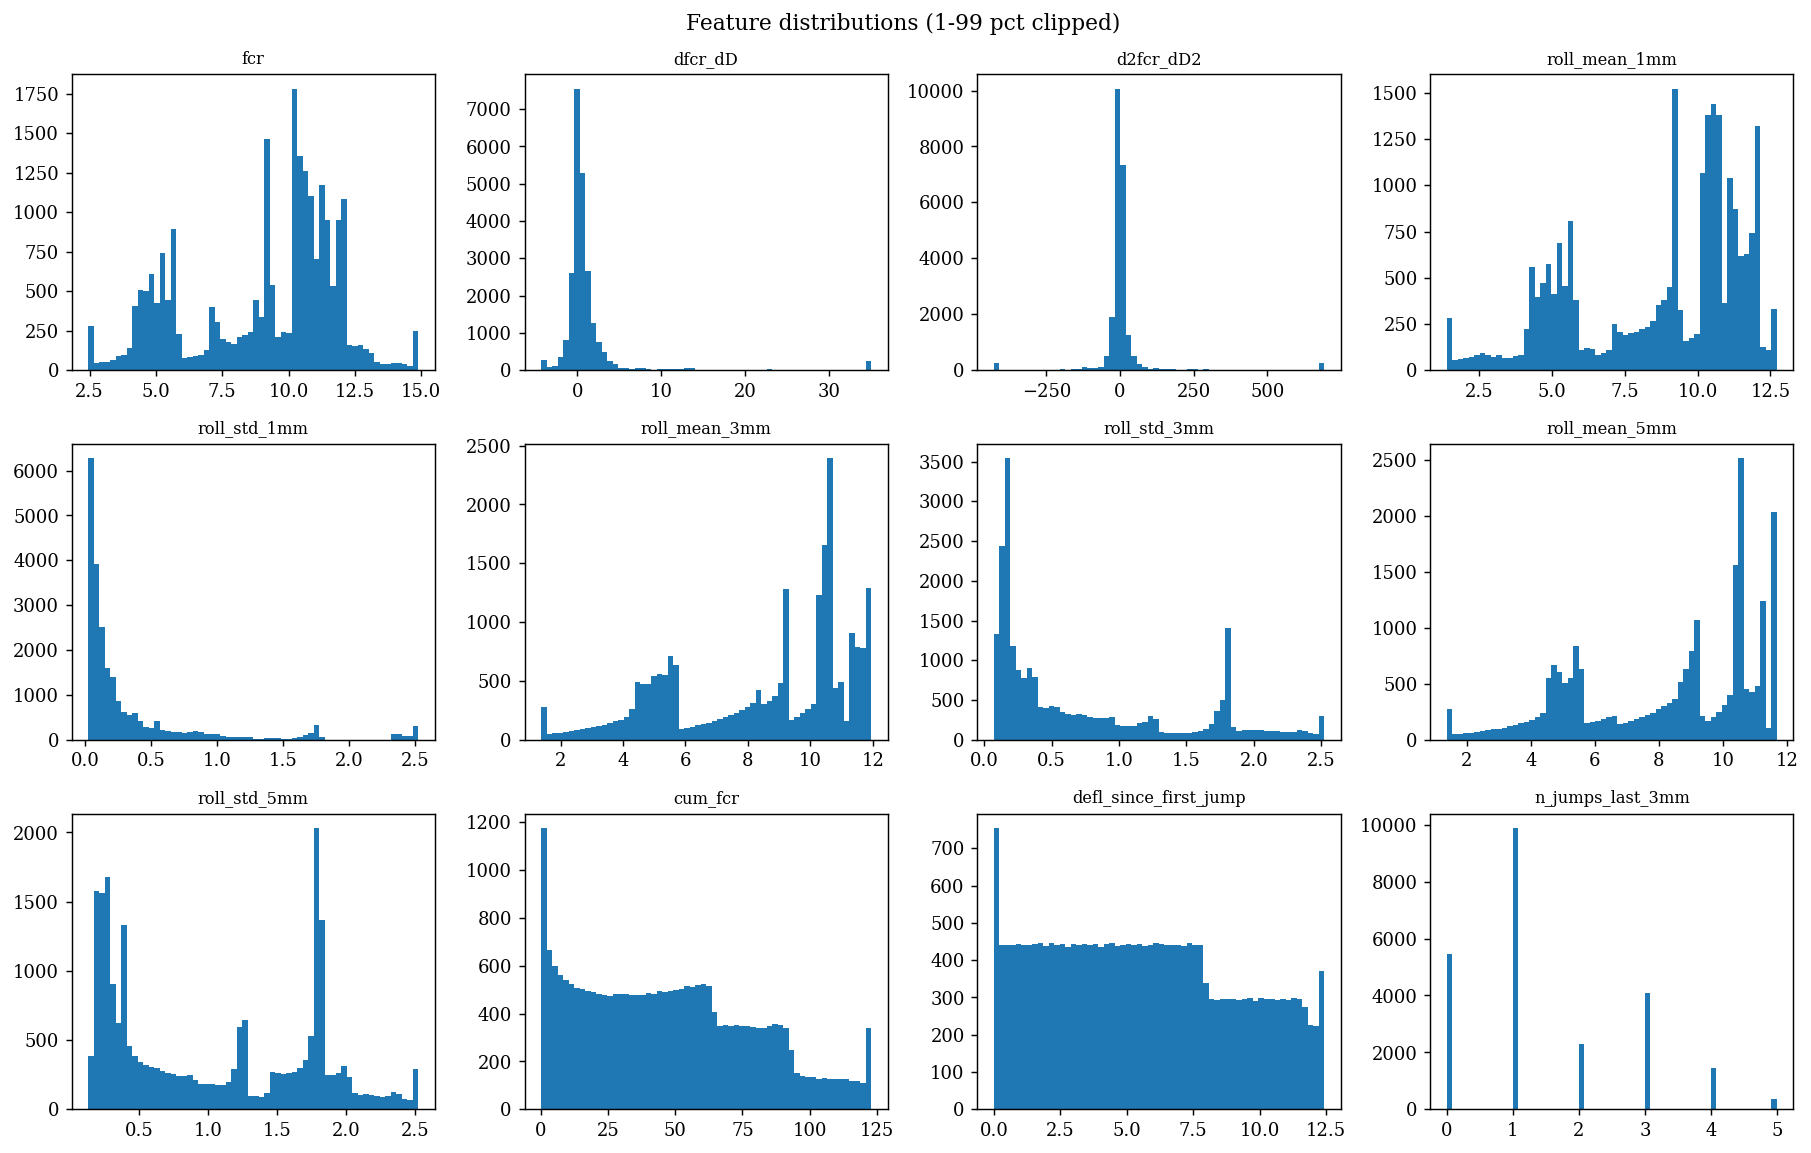

In [2]:
cols = [c for c in FEATURE_COLUMNS if c not in ('loading_rate', 'log_R0')]
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
for ax, c in zip(axes.ravel(), cols):
    lo, hi = df[c].quantile([0.01, 0.99])
    ax.hist(df[c].clip(lo, hi), bins=60, color='C0')
    ax.set_title(c, fontsize=9)
for ax in axes.ravel()[len(cols):]: ax.axis('off')
fig.suptitle('Feature distributions (1-99 pct clipped)'); fig.tight_layout()
fig.savefig(FIG / 'feature_distributions.png')

## Key features per stage

/var/folders/j9/02jnh31j4cvczjp1f9drgr3w0000gn/T/ipykernel_13294/1425012628.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[STAGE_NAMES[s] for s in order], showfliers=False)
/var/folders/j9/02jnh31j4cvczjp1f9drgr3w0000gn/T/ipykernel_13294/1425012628.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[STAGE_NAMES[s] for s in order], showfliers=False)
/var/folders/j9/02jnh31j4cvczjp1f9drgr3w0000gn/T/ipykernel_13294/1425012628.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[STAGE_NAMES[s] for s in order], showfliers=False)
/var/folders/j9/

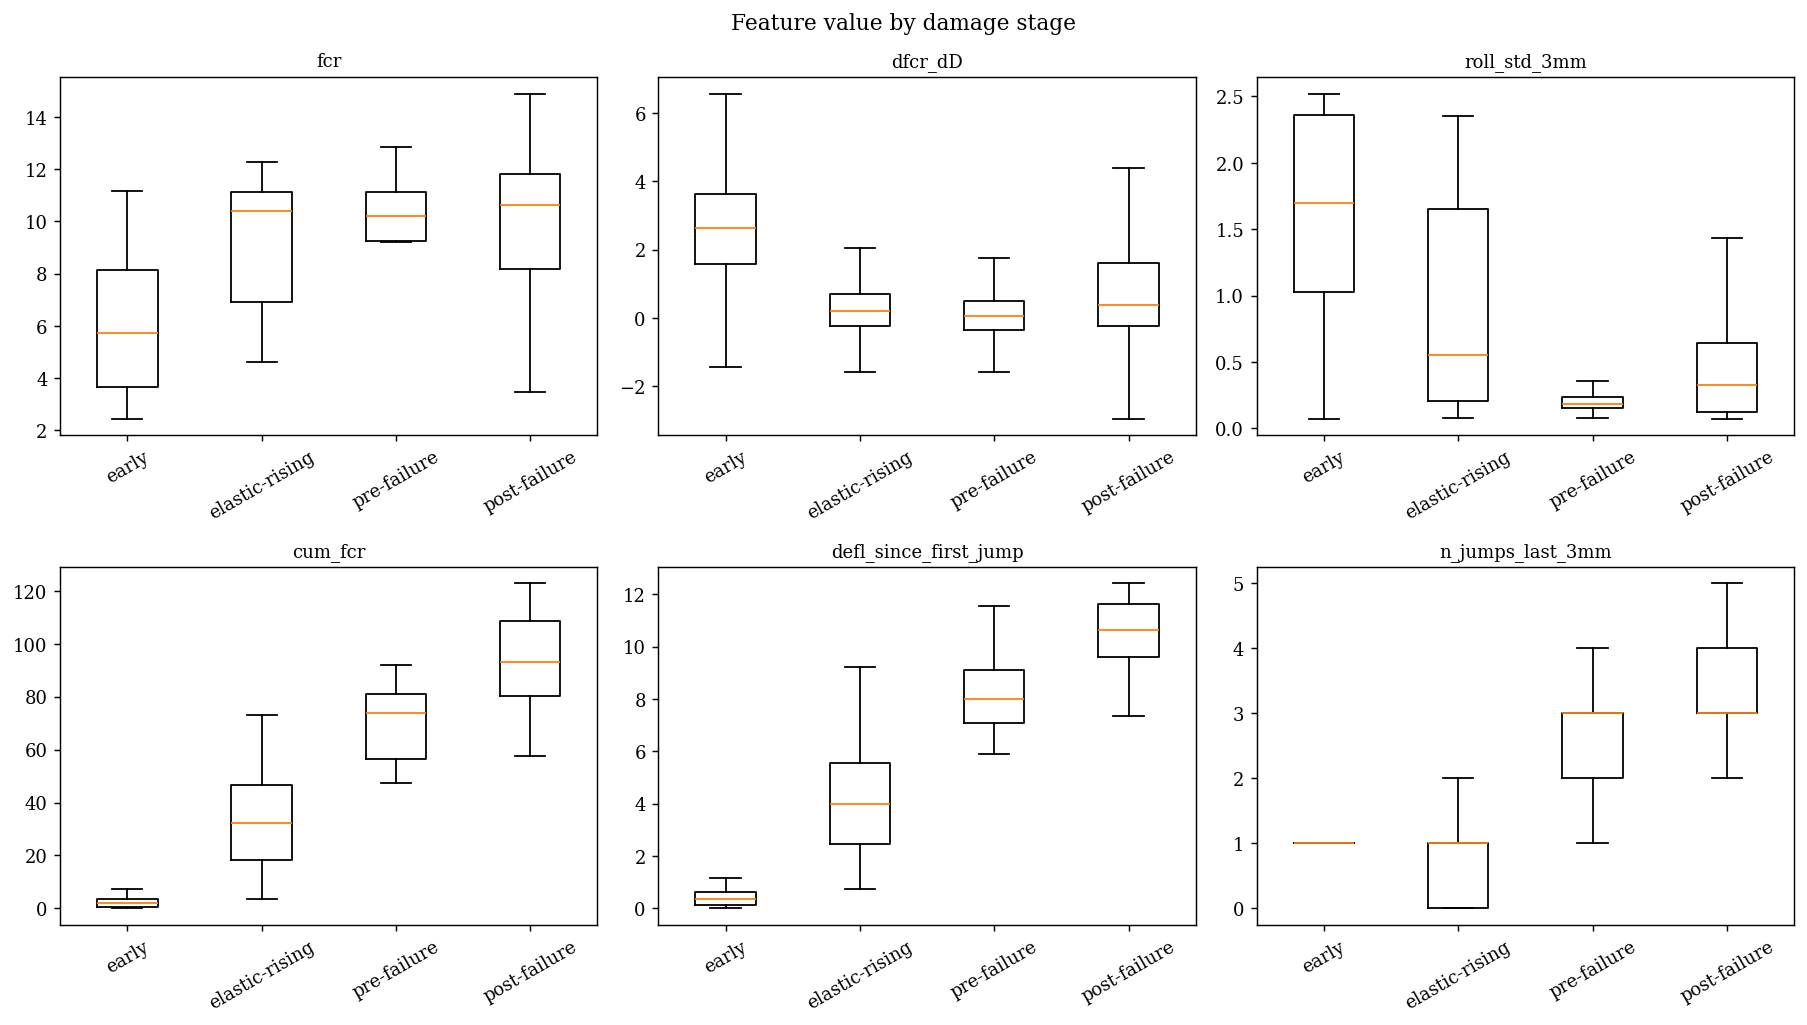

In [3]:
key = ['fcr', 'dfcr_dD', 'roll_std_3mm', 'cum_fcr', 'defl_since_first_jump', 'n_jumps_last_3mm']
order = [0, 1, 2, 3]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, c in zip(axes.ravel(), key):
    data = [df.loc[df.stage == s, c].clip(*df[c].quantile([0.01, 0.99])) for s in order]
    ax.boxplot(data, labels=[STAGE_NAMES[s] for s in order], showfliers=False)
    ax.set_title(c, fontsize=10); ax.tick_params(axis='x', rotation=30)
fig.suptitle('Feature value by damage stage'); fig.tight_layout()
fig.savefig(FIG / 'features_by_stage.png')

## Per-specimen feature vs deflection

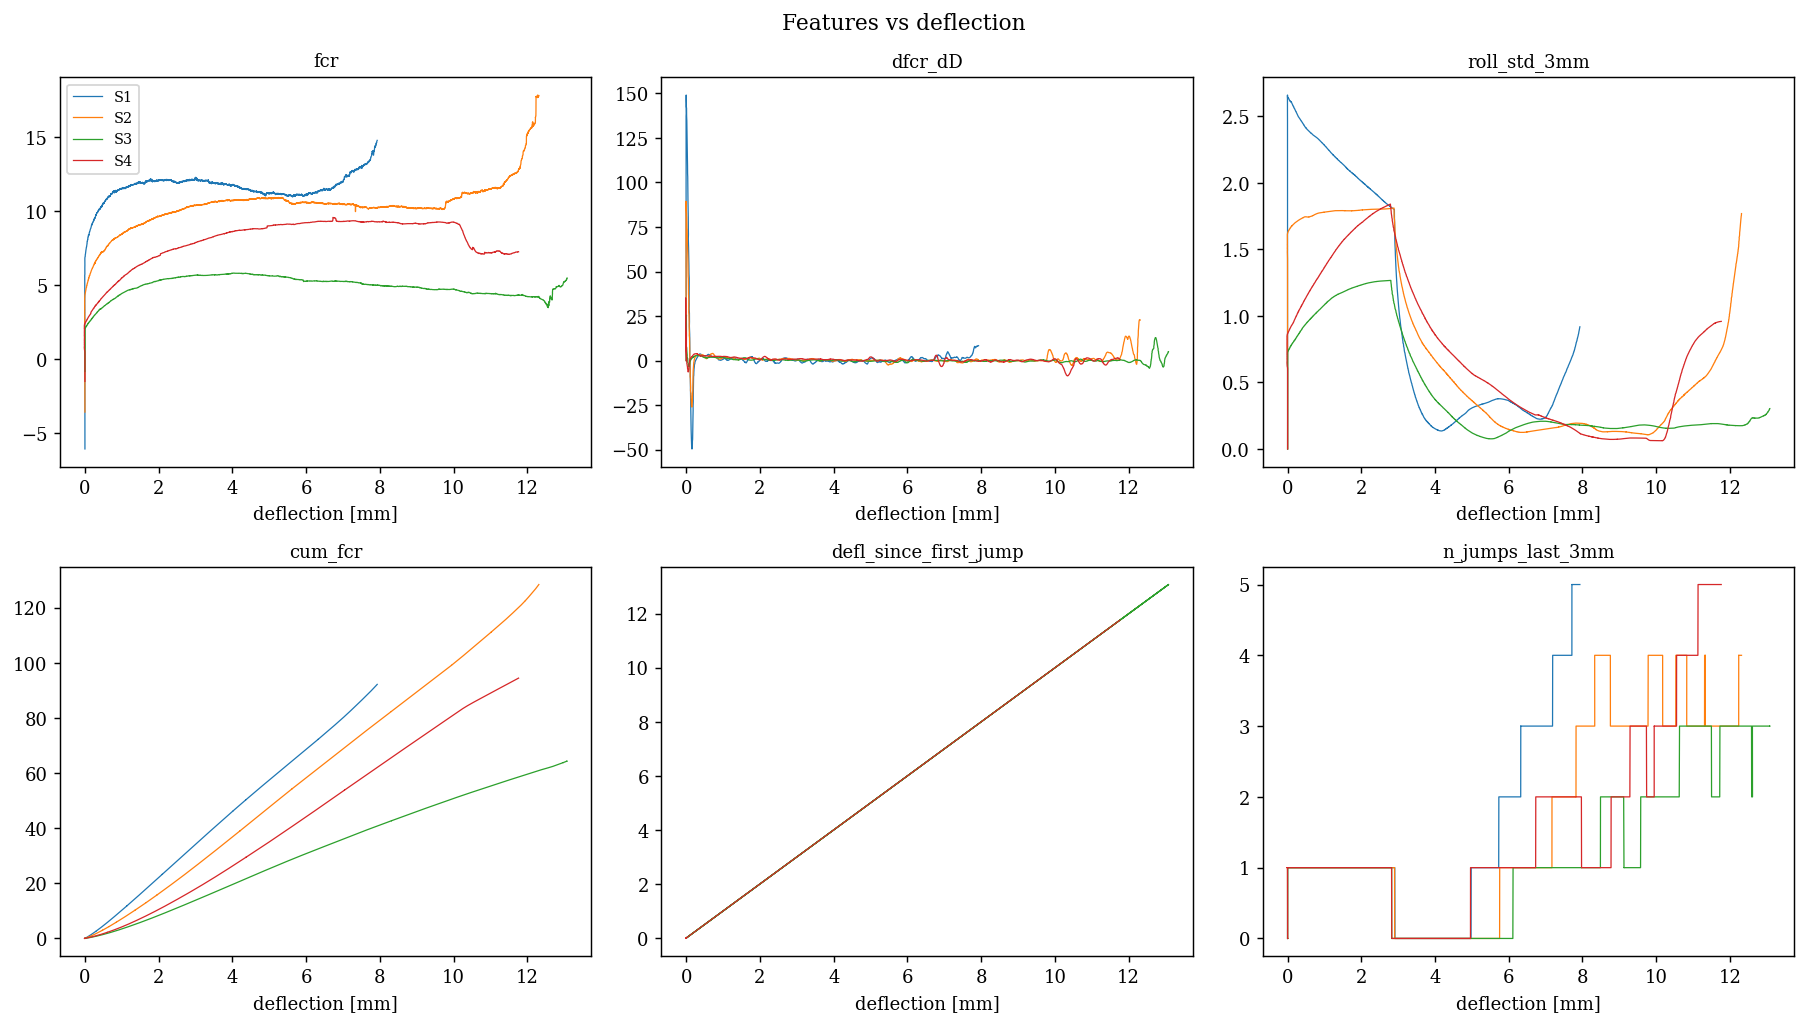

In [4]:
show = ['fcr', 'dfcr_dD', 'roll_std_3mm', 'cum_fcr', 'defl_since_first_jump', 'n_jumps_last_3mm']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, c in zip(axes.ravel(), show):
    for s, g in df.groupby('specimen'):
        ax.plot(g['deflection_mm'], g[c], lw=0.7, label=s)
    ax.set_title(c, fontsize=10); ax.set_xlabel('deflection [mm]')
axes.ravel()[0].legend(fontsize=8); fig.suptitle('Features vs deflection'); fig.tight_layout()
fig.savefig(FIG / 'features_vs_deflection.png')

## Correlation matrix

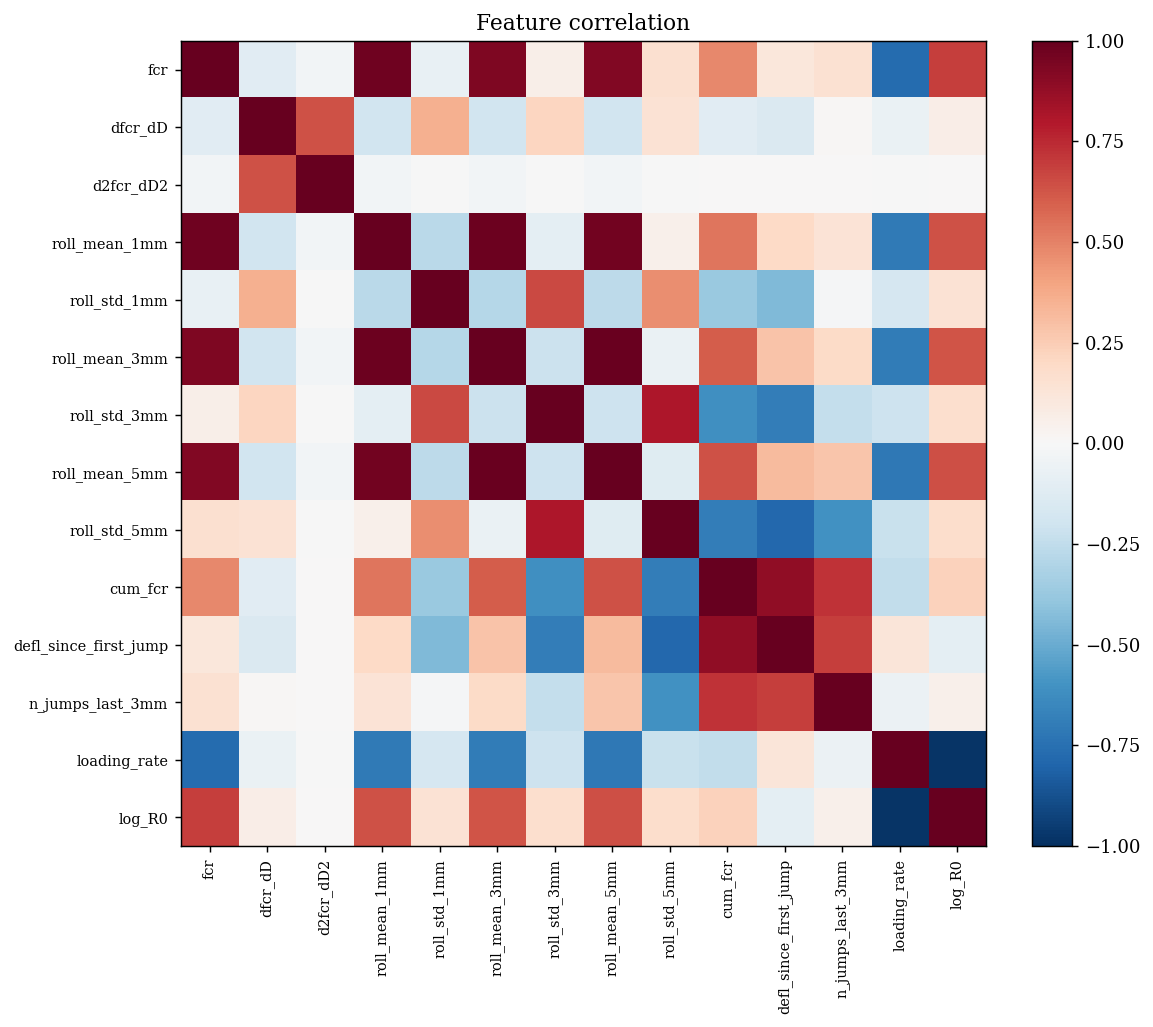

In [5]:
corr = df[FEATURE_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLUMNS))); ax.set_xticklabels(FEATURE_COLUMNS, rotation=90, fontsize=8)
ax.set_yticks(range(len(FEATURE_COLUMNS))); ax.set_yticklabels(FEATURE_COLUMNS, fontsize=8)
fig.colorbar(im, fraction=0.046); ax.set_title('Feature correlation'); fig.tight_layout()
fig.savefig(FIG / 'feature_correlation.png')